### Creating SQL database

In [60]:
import pandas as pd
import numpy as np
import keras
import sklearn
import sqlite3
from matplotlib import pyplot as plt

#connect to database
conn = sqlite3.connect('database.db')
cur = conn.cursor()

#creating table
cur.execute("""
CREATE TABLE IF NOT EXISTS spotify_features (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    "title" TEXT,
    "artist" TEXT,
    "top genre" TEXT,  -- Fixed space issue
    "year" INT,
    "bpm" FLOAT,
    "nrgy" FLOAT,
    "dnce" FLOAT,
    "dB" FLOAT,
    "live" FLOAT,
    "val" FLOAT,
    "dur" FLOAT,
    "acous" FLOAT,
    "spch" FLOAT,
    "pop" FLOAT
);
""")


### Loading all csvs into database

In [61]:
import os

folder = "SpotifyData/"

#adds all csv files to the database
for file in os.listdir(folder):
    file_path = os.path.join(folder, file)
    df = pd.read_csv(file_path)
    #drop the number column (use id in the database)
    df = df.drop(columns=["Number"])
    df.to_sql("spotify_features", conn, if_exists="append", index=False)

print("✅ All CSV files successfully loaded into the database!")




✅ All CSV files successfully loaded into the database!


### Importing x and y from the database

In [62]:
#use the first 10 columns after genre as features (x)
query_features = """
SELECT year, bpm, nrgy, dnce, dB, live, val, dur, acous, spch
FROM spotify_features;
"""
x = pd.read_sql(query_features, conn).to_numpy()

#use popularity as target (y)
query_pop = """
SELECT pop FROM spotify_features;
"""
y = pd.read_sql(query_pop, conn).to_numpy().flatten() 

### Defining x,y 

Text(0, 0.5, 'BPM')

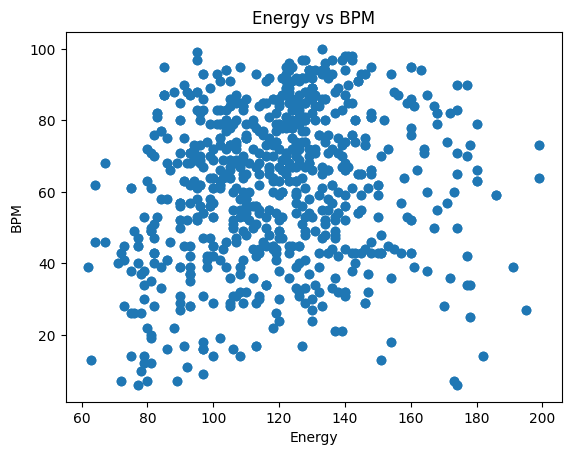

In [63]:
#x is the input data,
#y is the true popularity data we want to predict
plt.figure()
plt.title("Energy vs BPM")
plt.plot(x[:,1:2],x[:,2:3],'o') 
plt.xlabel("Energy")
plt.ylabel("BPM")

### Preprocessing data

In [64]:
import sklearn.model_selection
import sklearn.preprocessing

#Splits into train 80% and test 20%
x_train, x_test, y_train, y_test = sklearn.model_selection.train_test_split(x, y, test_size=0.2) 

#Scaling data
scalerX = sklearn.preprocessing.StandardScaler()
scalerY = sklearn.preprocessing.StandardScaler()

scalerX.fit(x_train)
scalerY.fit(y_train.reshape(-1,1))

X_train = scalerX.transform(x_train)
X_test = scalerX.transform(x_test) 
    
Y_train = scalerY.transform(y_train.reshape(-1,1))
Y_test = scalerY.transform(y_test.reshape(-1,1))

### Training a linear regression model

In [65]:
import sklearn.linear_model
regl = sklearn.linear_model.LinearRegression()
regl.fit(X_train,Y_train[:,0:1])
Y_pred = regl.predict(X_test)

### Predicting Values

Text(0.5, 1.0, 'Predicted vs True popularity')

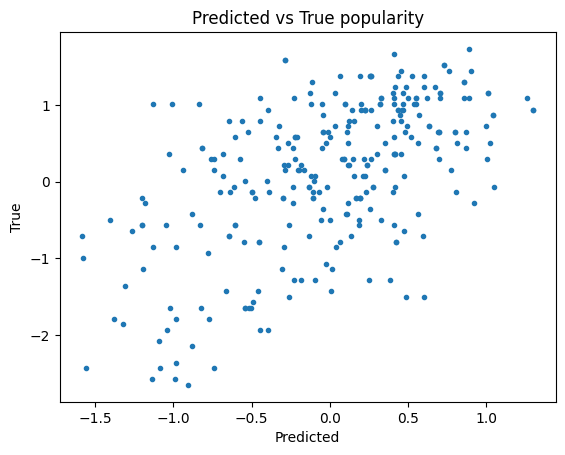

In [66]:
Y_pred = regl.predict(X_test)

plt.plot(Y_pred,Y_test,'.')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Predicted vs True popularity")


### Calculating MSE

In [67]:
mse = np.mean((Y_pred-Y_test[:,0:1])**2)
print("MSE on test data: " + str(mse))

MSE on test data: 0.6409177773396216


### Training a neural network

Epoch 1/20


c:\Users\aman\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.8264 - mse: 0.8264 - val_loss: 0.5885 - val_mse: 0.5885
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6135 - mse: 0.6135 - val_loss: 0.5425 - val_mse: 0.5425
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4785 - mse: 0.4785 - val_loss: 0.4940 - val_mse: 0.4940
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4152 - mse: 0.4152 - val_loss: 0.4791 - val_mse: 0.4791
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4425 - mse: 0.4425 - val_loss: 0.4830 - val_mse: 0.4830
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3959 - mse: 0.3959 - val_loss: 0.4609 - val_mse: 0.4609
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3739 - mse: 0.3739 - val_loss: 0.4461 - val_mse: 0.4461
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3684 - mse: 0.3684 - val_loss: 0.4355 - val_mse: 0.4355
Epoch 9/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3596 - mse: 0.3596 - v

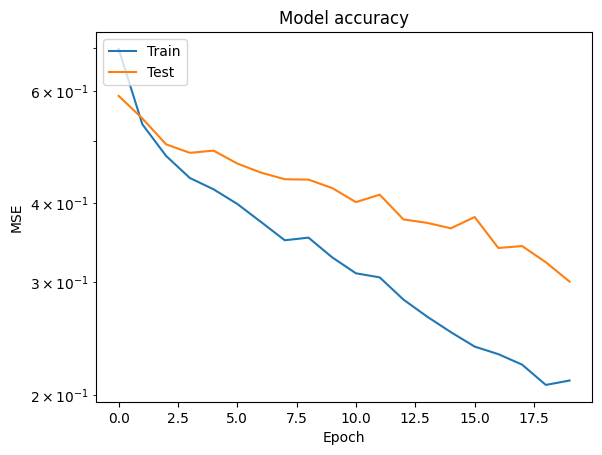

In [68]:
model = keras.models.Sequential()
#Defining each layer
model.add(keras.layers.Dense(100, input_dim=X_train.shape[1], \
activation='relu'))
model.add(keras.layers.Dense(500, activation='relu'))
model.add(keras.layers.Dense(1, activation=None))

model.compile(loss='mse', optimizer='adam', metrics=['mse'])

history = model.fit(X_train, Y_train[:,0:1], validation_data = \
(X_test,Y_test[:,0]), epochs=20, batch_size=64) 

plt.semilogy(history.history['mse'])
plt.semilogy (history.history['val_mse'])
plt.title('Model accuracy')
plt.ylabel('MSE')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'], loc='upper left')
plt.show()

### Neural Network predictions and MSE

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
MSE on test data: [0.30093336]


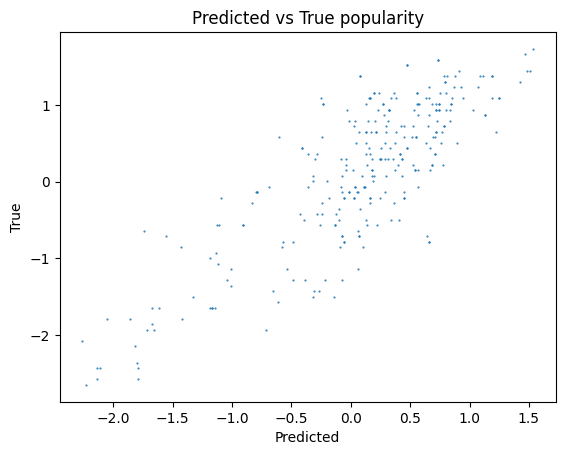

In [69]:
YNN_pred = model.predict(X_test)
plt.plot(YNN_pred,Y_test[:,0:1],'o',ms=0.5)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Predicted vs True popularity")


mse = np.mean((YNN_pred-Y_test[:,0:1])**2,axis=0)
print("MSE on test data: " + str(mse))

### Finding the most common genre, and its average popularity using SQL queries.

In [70]:
#this query groups the data by genre, counting the number of songs in each genre
#and orders by the counts in descending order
query = """
SELECT "top genre", COUNT(*) AS count
FROM spotify_features
GROUP BY "top genre"
ORDER BY count DESC
LIMIT 10;
"""
df_genres = pd.read_sql(query, conn)
print(df_genres)

#dance pop is the most common genre

#here the data is grouped by genre and the popularity is averaged
#this is then ordered descending
query = """
SELECT "top genre", AVG(pop) AS avg_popularity
FROM spotify_features
GROUP BY "top genre"
ORDER BY avg_popularity DESC
LIMIT 10;
"""

df_avg_pop = pd.read_sql(query, conn)
print(df_avg_pop)

#country rap has the highest average popularity

            top genre  count
0           dance pop    267
1     adult standards    186
2          album rock    154
3           glam rock     46
4  brill building pop     40
5            big room     36
6             europop     34
7            boy band     34
8                None     32
9          dance rock     30
                   top genre  avg_popularity
0                country rap           89.00
1                    emo rap           87.00
2                    dfw rap           84.80
3          conscious hip hop           84.00
4           canadian hip hop           84.00
5  canadian contemporary r&b           83.50
6             permanent wave           82.00
7                    brostep           81.50
8            electronic trap           81.00
9                modern rock           80.75
